# Deep Domain Adaptation: Deep CORAL (MNIST → USPS)

Deep Learning / SoftUni  
Aleksander Ginev  
August 2026

---

# Table of Contents

1. [Problem and Why It Matters](#1-problem-and-why-it-matters)
2. [The Math Behind Deep CORAL](#2-the-math-behind-deep-coral)
3. [Getting and Preparing the Data](#3-getting-and-preparing-the-data)
   - [3.1 Loading MNIST and USPS as PyTorch Datasets](#31-loading-mnist-and-usps-as-pytorch-datasets)
   - [3.2 Matching Image Sizes and Data Loaders](#32-matching-image-sizes-and-data-loaders)
   - [3.3 Visualizing the Domain Gap](#33-visualizing-the-domain-gap)
4. [Checking the Domain Shift Visually (Feature Space)](#4-checking-the-domain-shift-visually-feature-space)
   - [4.1 PCA on Untrained CNN Features](#41-pca-on-untrained-cnn-features)
   - [4.2 t-SNE Analysis](#42-t-sne-analysis)
5. [Baseline: Training a Source-Only CNN (MNIST)](#5-baseline-training-a-source-only-cnn-mnist)
6. [Applying Deep CORAL (Joint Feature & Classification Loss)](#6-applying-deep-coral-joint-feature--classification-loss)
7. [Does Standard Fine-Tuning or Simple Rescaling Compare?](#7-does-standard-fine-tuning-or-simple-rescaling-compare)
8. [Results and Sanity Checks](#8-results-and-sanity-checks)
9. [Conclusion](#9-conclusion)
10. [References](#10-references)

In [1]:
!pip install torch torchvision
%matplotlib inline
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# needed due to mac os for The Kernel Restart / Kernel Crash during t-SNE execution caused by OpenMP library
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"

import urllib.request
import ssl

ssl_context = ssl._create_unverified_context()
urllib.request.install_opener(urllib.request.build_opener(urllib.request.HTTPSHandler(context=ssl_context)))
ssl._create_default_https_context = ssl._create_unverified_context

from torchvision import transforms, datasets

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# if no gpu defaults cpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Libraries loaded successfully. Running on device: {device}")

Libraries loaded successfully. Running on device: cpu


# 1. Problem and Why It Matters

Most standard Machine Learning and Deep Learning pipelines rely on the fundamental independent and identically distributed (i.i.d.) assumption, which states that both the training and testing samples are drawn independently from the same underlying probability distribution:

$$
P_S(X, Y) = P_T(X, Y)
$$

In real-world computer vision applications, however, this assumption rarely holds. A Convolutional Neural Network (CNN) trained on clean, high-contrast, centered handwritten digits (such as MNIST) often experiences a significant drop in performance when evaluated on images captured under different conditions, such as USPS handwritten digits. Although both datasets contain the same semantic classes (digits 0–9), they differ in image resolution, stroke thickness, contrast, background noise, and writing style.

This discrepancy between the source and target data distributions is known as domain shift. When labels are unavailable in the target domain, traditional supervised retraining is no longer possible.

To overcome this limitation, this project investigates Unsupervised Domain Adaptation (UDA). The objective is to learn feature representations that remain discriminative for the source task while simultaneously becoming invariant to the domain from which they originate.

The learning setup consists of:

- Labeled Source Domain ($S$): MNIST images and labels $(X_S, Y_S)$
- Unlabeled Target Domain ($T$): USPS images $(X_T)$

The USPS labels are never used during training and are reserved exclusively for the final evaluation of the adapted model.

---

# 2. The Math Behind Deep CORAL

Deep CORAL (Deep CORrelation ALignment) extends the classical CORAL algorithm by incorporating covariance alignment directly into the optimization process of a deep neural network.

The original CORAL method aligns the second-order statistics (covariance matrices) of the source and target feature distributions through a linear transformation. Deep CORAL replaces this explicit transformation with a differentiable loss function that can be optimized jointly with the classification objective using backpropagation.

During training, a shared feature extractor

$$
f_\theta(\cdot)
$$

produces deep feature representations for both source and target samples.

Let

- $D_S \in \mathbb{R}^{n_S \times d}$ denote the source feature matrix,
- $D_T \in \mathbb{R}^{n_T \times d}$ denote the target feature matrix,

where $d$ is the dimensionality of the learned feature space.

The covariance matrix of the source features is computed as

$$
C_S =
\frac{1}{n_S-1}
\left(
D_S^\top D_S
-
\frac{1}{n_S}
(\mathbf{1}^\top D_S)^\top
(\mathbf{1}^\top D_S)
\right),
$$

while the covariance matrix of the target features is

$$
C_T =
\frac{1}{n_T-1}
\left(
D_T^\top D_T
-
\frac{1}{n_T}
(\mathbf{1}^\top D_T)^\top
(\mathbf{1}^\top D_T)
\right).
$$

Deep CORAL encourages both domains to share similar second-order statistics by minimizing the squared Frobenius distance between these covariance matrices:

$$
\mathcal{L}_{\mathrm{CORAL}}
=
\frac{1}{4d^2}
\left\|
C_S - C_T
\right\|_F^2.
$$

Here,

- $\|\cdot\|_F$ denotes the Frobenius norm,
- $d$ is the dimensionality of the deep feature representation.

The neural network is trained using a joint optimization objective composed of the standard supervised classification loss on the source domain together with the CORAL alignment loss:

$$
\mathcal{L}
=
\mathcal{L}_{\mathrm{classification}}(D_S,Y_S)
+
\lambda\,
\mathcal{L}_{\mathrm{CORAL}}(D_S,D_T).
$$

The hyperparameter $\lambda$ controls the trade-off between two competing objectives:

- minimizing the classification error on the labeled source domain;
- aligning the feature distributions of the source and target domains.

A larger value of $\lambda$ emphasizes domain invariance, while a smaller value prioritizes classification accuracy on the source dataset. Selecting an appropriate balance is essential for achieving strong transfer performance on the unlabeled target domain.

# 3. Getting and preparing the data
## 3.1 & 3.2 Loading and Resizing Datasets
MNIST images are $28 \times 28$ pixels, while USPS images are historically $16 \times 16$. To feed both domains into a shared CNN architecture, we resize USPS images to $28 \times 28$ and normalize both datasets to $[-1, 1]$.

In [2]:
transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# load MNIST-Source
mnist_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
mnist_test = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# load USPS-Target
usps_train = datasets.USPS(root='./data', train=True, download=True, transform=transform)
usps_test = datasets.USPS(root='./data', train=False, download=True, transform=transform)

BATCH_SIZE = 128

source_loader = DataLoader(mnist_train, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
target_loader = DataLoader(usps_train, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
target_test_loader = DataLoader(usps_test, batch_size=BATCH_SIZE, shuffle=False)

print(f"MNIST Train Batches: {len(source_loader)} | USPS Train Batches: {len(target_loader)}")

MNIST Train Batches: 468 | USPS Train Batches: 56


## 3.3 Visualizing the Domain Gap

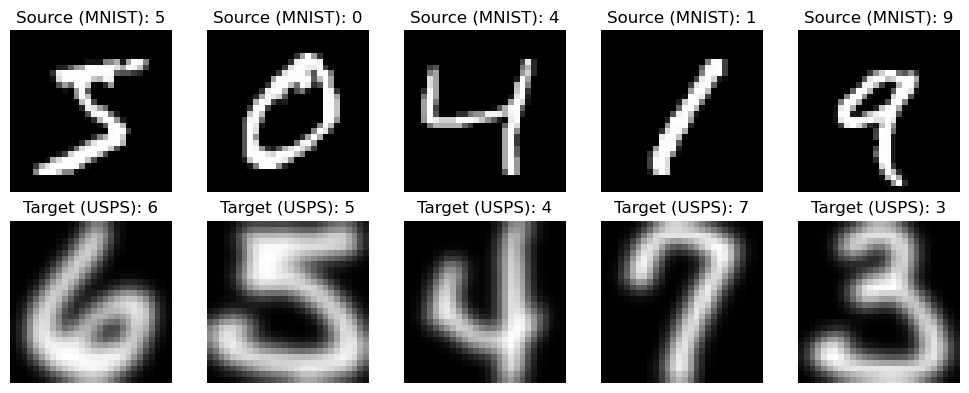

In [3]:
def plot_samples(source_ds, target_ds):
    fig, axes = plt.subplots(2, 5, figsize=(10, 4))
    for i in range(5):
        axes[0, i].imshow(source_ds[i][0].squeeze(), cmap='gray')
        axes[0, i].set_title(f"Source (MNIST): {source_ds[i][1]}")
        axes[0, i].axis('off')
        
        axes[1, i].imshow(target_ds[i][0].squeeze(), cmap='gray')
        axes[1, i].set_title(f"Target (USPS): {target_ds[i][1]}")
        axes[1, i].axis('off')
    plt.tight_layout()
    plt.show()

plot_samples(mnist_train, usps_train)

# 4. Checking the Domain Shift Visually (Feature Space)

Before applying any domain adaptation technique, it is useful to examine whether a measurable distribution shift exists between the source and target domains in the learned feature space.

To achieve this, batches of images from both MNIST and USPS are passed through the feature extractor of an untrained Convolutional Neural Network (CNN). Since the network has not yet learned task-specific representations, the extracted features primarily reflect the inherent differences between the two image distributions rather than semantic information.

Because these feature vectors are high-dimensional, they are projected into two-dimensional space using two complementary dimensionality reduction techniques:

- Principal Component Analysis (PCA), which provides a linear projection that preserves the directions of maximum variance.
- t-distributed Stochastic Neighbor Embedding (t-SNE), which performs a nonlinear projection designed to preserve local neighborhood relationships in the feature space.

If a significant domain shift exists, the projected MNIST and USPS features are expected to form distinct clusters, indicating that samples from the two datasets occupy different regions of the feature space before adaptation. Conversely, successful domain adaptation should reduce this separation by encouraging the feature distributions to overlap while maintaining class-discriminative information.

In [ ]:
class CNNFeatureExtractor(nn.Module):
    def __init__(self):
        super(CNNFeatureExtractor, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # 14x14
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)  # 7x7
        )
        self.fc_domain = nn.Sequential(
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU()
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.fc_domain(x)
        return x

# Extract sample features
untrained_net = CNNFeatureExtractor().to(device)
untrained_net.eval()

src_img, _ = next(iter(source_loader))
tgt_img, _ = next(iter(target_loader))

with torch.no_grad():
    src_feat = untrained_net(src_img.to(device)).cpu().numpy()
    tgt_feat = untrained_net(tgt_img.to(device)).cpu().numpy()

X_comb = np.vstack([src_feat, tgt_feat])
domain_labels = np.array([0]*len(src_feat) + [1]*len(tgt_feat))

# 4.1 PCA & 4.2 t-SNE
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_comb)

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_comb)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.scatter(X_pca[domain_labels==0, 0], X_pca[domain_labels==0, 1], alpha=0.6, label='MNIST (Source)')
ax1.scatter(X_pca[domain_labels==1, 0], X_pca[domain_labels==1, 1], alpha=0.6, label='USPS (Target)')
ax1.set_title("PCA of Untrained Deep Features")
ax1.legend()

ax2.scatter(X_tsne[domain_labels==0, 0], X_tsne[domain_labels==0, 1], alpha=0.6, label='MNIST (Source)')
ax2.scatter(X_tsne[domain_labels==1, 0], X_tsne[domain_labels==1, 1], alpha=0.6, label='USPS (Target)')
ax2.set_title("t-SNE of Untrained Deep Features")
ax2.legend()
plt.show()